<div style="background-color:#E6F2FF; padding:20px; border-radius:8px; text-align:center;">
    <h1 style="color:#1E3A8A; margin-bottom:10px;">Loan Approval Prediction </h1>
    <p style="font-size:16px; color:#1A1A1A; line-height:1.6;">
        This project aims to predict loan approval outcomes using machine learning techniques. 
        Both Random Forest and Gradient Boosting models were trained and evaluated on the same dataset. 
        The goal is to identify the best performing model while ensuring stability, robustness, and interpretability.
    </p>
</div>


<h2 style="
    font-family:'Verdana', sans-serif;
    color:#006400;           /* Dark Green */
    background: linear-gradient(90deg, #C8E6C9, #66BB6A); /* gradient background */
    padding:10px 20px;
    border-radius:25px;
    display:inline-block;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.2);
">
    Random Forest Classifier
</h2>

## 1] IMPORT REQUIRED LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2] LOAD DATASET

In [2]:
df=pd.read_csv('loan_status_prediction.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## 3] BASIC DATA EXPLORATION

In [3]:
df.shape

(614, 13)

In [4]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [8]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## 4] DATA CLEANING

##### 4.1 Drop Unnecessary Column

In [9]:
df.drop('Loan_ID', axis=1, inplace=True)

##### 4.2 Fill Missing Values (Categorical → Mode)

In [10]:
columns=['Gender','Married','Self_Employed','Dependents']

In [11]:
for col in columns:
    df[col]=df[col].fillna(df[col].mode()[0])

In [12]:
df.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

##### 4.3 Fill Missing Values (Numerical → Mean)

In [13]:
column=['LoanAmount','Loan_Amount_Term','Credit_History']

In [14]:
for col in column:
    df[col]=df[col].fillna(df[col].mean())

In [15]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [16]:
df.dtypes

Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

## 5] DATA TRANSFORMATION

#### 5.1 Convert Dependents column

In [17]:
# Dependents column is still a string ('3+'), so convert '3+' to numeric so the model can process it.

df['Dependents'] = df['Dependents'].replace('3+', 3).astype(float)

In [18]:
import warnings
warnings.simplefilter(action='ignore',category=FutureWarning)

#### 5.2 Encode Categorical Variables

In [19]:
# Mapping for each categorical column.
df.replace({
    'Gender': {'Male':1, 'Female':0},
    'Married': {'Yes':1, 'No':0},
    'Education': {'Graduate':1, 'Not Graduate':0},
    'Self_Employed': {'Yes':1, 'No':0},
    'Property_Area': {'Urban':2, 'Semiurban':1, 'Rural':0},
    'Loan_Status': {'Y':1, 'N':0}
}, inplace=True)

In [20]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0.0,1,0,5849,0.0,146.412162,360.0,1.0,2,1
1,1,1,1.0,1,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,1,1,0.0,1,1,3000,0.0,66.000000,360.0,1.0,2,1
3,1,1,0.0,0,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,1,0,0.0,1,0,6000,0.0,141.000000,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0.0,1,0,2900,0.0,71.000000,360.0,1.0,0,1
610,1,1,3.0,1,0,4106,0.0,40.000000,180.0,1.0,0,1
611,1,1,1.0,1,0,8072,240.0,253.000000,360.0,1.0,2,1
612,1,1,2.0,1,0,7583,0.0,187.000000,360.0,1.0,2,1


## 6] FEATURE & TARGET SELECTION

In [21]:
# DEFINING FEATURES (X) AND TARGET (y).

X=df.drop('Loan_Status',axis=1)
y=df['Loan_Status']

In [22]:
df[:3]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0.0,1,0,5849,0.0,146.412162,360.0,1.0,2,1
1,1,1,1.0,1,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,1,1,0.0,1,1,3000,0.0,66.000000,360.0,1.0,2,1


In [23]:
X[:3]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0.0,1,0,5849,0.0,146.412162,360.0,1.0,2
1,1,1,1.0,1,0,4583,1508.0,128.000000,360.0,1.0,0
2,1,1,0.0,1,1,3000,0.0,66.000000,360.0,1.0,2


In [24]:
y

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64

# 7] TRAIN–TEST SPLIT

In [25]:
# SPLITTING DATA INTO TRAIN AND TEST SETS.

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# 8. FEATURE SCALING

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print the scaled training data
print(X_train_scaled)

# Print the scaled test data
print(X_test_scaled)

[[ 0.48339253  0.75744171 -0.72327513 ...  0.29449206 -0.00685711
  -0.04695148]
 [ 0.48339253  0.75744171 -0.72327513 ...  0.29449206  0.44784556
  -0.04695148]
 [ 0.48339253  0.75744171  1.26068067 ...  0.29449206  0.44784556
  -0.04695148]
 ...
 [-2.06871213 -1.3202336  -0.72327513 ...  0.29449206  0.44784556
   1.23378058]
 [-2.06871213  0.75744171 -0.72327513 ... -1.50172657  0.44784556
  -0.04695148]
 [ 0.48339253  0.75744171 -0.72327513 ...  0.29449206  0.44784556
   1.23378058]]
[[ 0.48339253  0.75744171 -0.72327513 ...  0.29449206  0.44784556
  -0.04695148]
 [ 0.48339253  0.75744171 -0.72327513 ...  0.29449206 -0.00685711
  -0.04695148]
 [ 0.48339253  0.75744171  1.26068067 ...  0.29449206  0.44784556
  -1.32768354]
 ...
 [ 0.48339253  0.75744171  0.26870277 ...  2.09071068  0.44784556
  -0.04695148]
 [ 0.48339253  0.75744171  1.26068067 ...  0.29449206  0.44784556
   1.23378058]
 [ 0.48339253  0.75744171 -0.72327513 ... -2.39983588  0.44784556
   1.23378058]]


# 9] RANDOM FOREST CLASSIFIER MODEL.

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model.
model=RandomForestClassifier(n_estimators=200,random_state=42)

In [28]:
# Train the model on the training data.
model.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
# Make predictions on the test data.
y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1])

# 10. MODEL EVALUATION

In [30]:
# MODEL PERFORMANCE EVALUATION

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy of the model.
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:",accuracy)

# Confusion Matrix.
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n",cm)

# Classification Report (Precision, Recall, F1-score)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7642276422764228

Confusion Matrix:
 [[18 25]
 [ 4 76]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.42      0.55        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.79      0.68      0.70       123
weighted avg       0.78      0.76      0.74       123



# 11] CONFUSION MATRIX PLOT

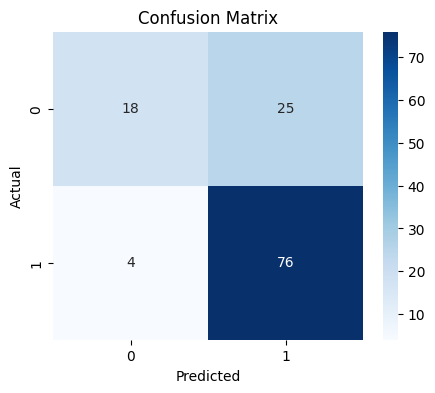

In [31]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<p style="font-size:18px; font-weight:bold; line-height:1.5; background-color:#FFFACD; padding:10px; border-radius:5px;">
After training the Random Forest model, I use a second model to see if it gives better accuracy. 
Using another model helps me compare results and choose the best one for my data.
</p>

<h2 style="
    font-family:'Verdana', sans-serif;
    color:#8B0000;           /* Dark Red */
    background: linear-gradient(90deg, #FFDAB9, #FF7F50); /* gradient background */
    padding:10px 20px;
    border-radius:25px;
    display:inline-block;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.2);
">
    Gradient Boosting Classifier
</h2>

<p style="font-size:16px; line-height:1.5; margin-top:10px; color:#333;">
Gradient Boosting Classifier was trained on the same dataset to demonstrate a sequential ensemble approach. 
It aims to reduce prediction errors iteratively and improve accuracy, complementing the Random Forest model for comparison.
</p>

In [32]:
# 1.Import Model
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [33]:
# 2.Create & Train Model
gbc = GradientBoostingClassifier(n_estimators=150,learning_rate=0.05,max_depth=3,random_state=42)

gbc.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,150
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [34]:
# 3.Make Predictions
y_pred= gbc.predict(X_test)
y_pred

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [35]:
# 4.Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Gradient Boosting Accuracy:",accuracy_score(y_test,y_pred))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))

Gradient Boosting Accuracy: 0.7642276422764228

Confusion Matrix:
 [[19 24]
 [ 5 75]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.44      0.57        43
           1       0.76      0.94      0.84        80

    accuracy                           0.76       123
   macro avg       0.77      0.69      0.70       123
weighted avg       0.77      0.76      0.74       123



<p style="font-size:18px; font-weight:bold; line-height:1.5; background-color:#FFFACD; padding:10px; border-radius:5px;">
Both Random Forest and Gradient Boosting models were trained and evaluated on the same dataset. 
The two models achieved similar accuracy scores on the test data. However, Gradient Boosting was included to demonstrate model 
comparison and improvement attempts beyond a baseline ensemble method. Since both models performed similarly, Random Forest was 
selected as the final model due to its stability, robustness, and simpler interpretability for this dataset.
</p>